In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import GaussianNB


In [4]:
data = load_iris()

In [7]:
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

df = pd.concat([X,y], axis=1)

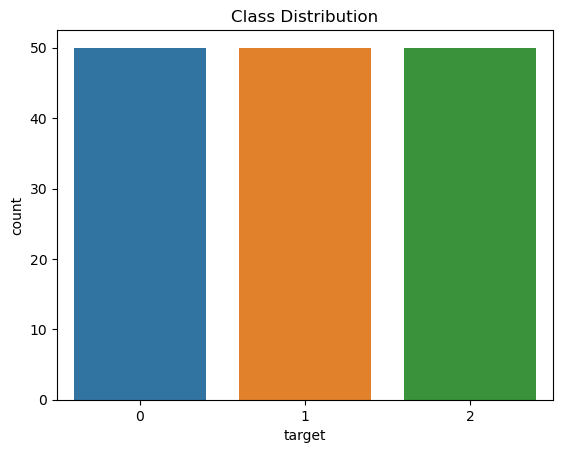

In [8]:
sns.countplot(x="target", data=df)
plt.title("Class Distribution")
plt.show()

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

In [10]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)

GaussianNB()

In [11]:
y_pred_nb = gnb.predict(X_test)

In [12]:
acc_nb = accuracy_score(y_test, y_pred_nb)
acc_nb

1.0

In [13]:
def summarize_by_class(X,y):
    summaries = {}

    for cls in np.unique(y):
        X_cls = X[y == cls]
        summaries[cls] = {
        "mean": X_cls.mean(axis=0),
        "var": X_cls.var(axis=0),
        "prior": X_cls.shape[0] / X.shape[0]
        }
    return summaries

In [14]:
def gaussian_pdf(x, mean, var):
    eps = 1e-9
    coefficient = 1 / np.sqrt(2 * np.pi * var + eps)
    exponent = np.exp(- (x - mean) ** 2 / (2 * var + eps))
    return coefficient * exponent
    

In [21]:
def predict_one(x, summaries):
    posteriors = {}

    for cls, stats in summaries.items():
        prior = np.log(stats["prior"])
        likelihood = np.sum(
                np.log(gaussian_pdf(x, stats["mean"], stats["var"]))
        )
        posteriors[cls] = prior + likelihood

    return max(posteriors, key=posteriors.get)

In [22]:
def predict(X, summaries):
    return np.array([predict_one(x, summaries) for x in X])

In [23]:
summaries = summarize_by_class(
    X_train.values,
    y_train.values
)

y_pred_custom = predict(X_test.values, summaries)

acc_custom = accuracy_score(y_test, y_pred_custom)
acc_custom

1.0

In [24]:
print("Sklearn GaussianNB Accuracy:", acc_nb)
print("Custom Naive Bayes Accuracy:", acc_custom)

Sklearn GaussianNB Accuracy: 1.0
Custom Naive Bayes Accuracy: 1.0
